# Notebook 11: Carbon Dispersal Impact

**Purpose:** Visually demonstrate and analyze the spatial carbon dispersal impact before (fixed-time) and after (PPO) reinforcement learning light optimization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style="white")

with open("../reports/fixed_time_metrics.json") as f:
    fixed_m = json.load(f)
with open("../reports/ppo_training/improvements.json") as f:
    ppo_data = json.load(f)
    ppo_m = ppo_data["ppo_metrics"]


### Hotspot and Spatial Distribution Contrast Plot

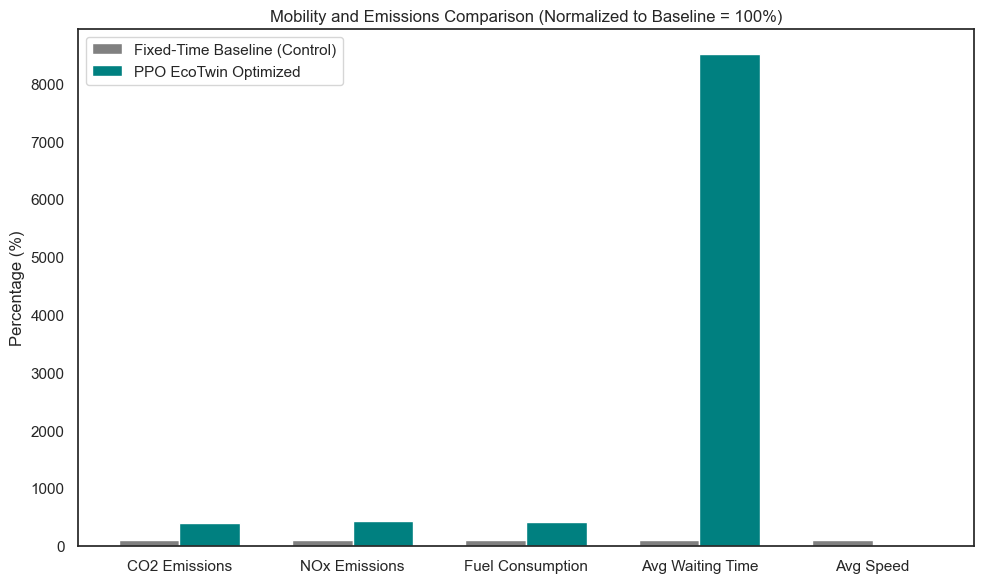

In [2]:
categories = ["CO2 Emissions", "NOx Emissions", "Fuel Consumption", "Avg Waiting Time", "Avg Speed"]
# Normalize to percentage of baseline
fixed_vals = [100.0] * 5
ppo_vals = [
    (ppo_m["total_co2_mg"] / fixed_m["total_co2_mg"]) * 100,
    (ppo_m["total_nox_mg"] / fixed_m["total_nox_mg"]) * 100,
    (ppo_m["total_fuel_ml"] / fixed_m["total_fuel_ml"]) * 100,
    (ppo_m["average_waiting_time_s"] / fixed_m["average_waiting_time_s"]) * 100,
    (ppo_m["average_speed_kmh"] / fixed_m["average_speed_kmh"]) * 100,
]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, fixed_vals, width, label="Fixed-Time Baseline (Control)", color="gray")
plt.bar(x + width/2, ppo_vals, width, label="PPO EcoTwin Optimized", color="teal")
plt.title("Mobility and Emissions Comparison (Normalized to Baseline = 100%)")
plt.xticks(x, categories)
plt.ylabel("Percentage (%)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/spatial/carbon_dispersal_comparison.png", dpi=300)
plt.show()
